# GPA Analyzer & Predictor

Run this notebook from top to bottom. It uses `results.csv` if present, otherwise it falls back to `sample_results.csv`.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from gpa_core import (
    compute_cgpa,
    compute_gpa,
    load_data,
    scenario_projection,
    target_cgpa_advice,
    trend_predict,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
csv_path = Path("results.csv") if Path("results.csv").exists() else Path("sample_results.csv")
df, validation_summary = load_data(csv_path)

print(f"Loaded: {csv_path}")
if validation_summary.get("error"):
    print(validation_summary["error"])
print(f"Input rows: {validation_summary['input_rows']}")
print(f"Dropped rows: {validation_summary['dropped_rows']}")
print(f"Invalid grade rows: {validation_summary['invalid_grade_rows']}")
print(f"Invalid units rows: {validation_summary['invalid_units_rows']}")
print(f"Missing value rows: {validation_summary['missing_value_rows']}")
if validation_summary.get("missing_columns"):
    print(f"Missing columns: {validation_summary['missing_columns']}")

df

Loaded: sample_results.csv
Input rows: 23
Dropped rows: 0
Invalid grade rows: 0
Invalid units rows: 0
Missing value rows: 0


,semester,course,units,grade,grade_point,quality_points
0,100L First,MTH101,3,A,5.0,15.0
1,100L First,PHY101,3,B,4.0,12.0
2,100L First,CHM101,3,C,3.0,9.0
3,100L First,GST101,2,A,5.0,10.0
4,100L First,CSC101,2,B,4.0,8.0
5,100L First,BIO101,3,D,2.0,6.0
6,100L Second,MTH102,3,B,4.0,12.0
7,100L Second,PHY102,3,C,3.0,9.0
8,100L Second,CHM102,3,B,4.0,12.0
9,100L Second,GST102,2,A,5.0,10.0


In [5]:
gpa_table = compute_gpa(df)
cgpa_table, final_cgpa = compute_cgpa(df)

print(f"Final CGPA: {final_cgpa:.2f}")
cgpa_table

Final CGPA: 3.76


,semester,total_units,quality_points,gpa,cumulative_units,cumulative_quality_points,cgpa
0,100L First,16,60.0,3.75,16,60.0,3.75
1,100L Second,16,53.0,3.31,32,113.0,3.53
2,200L First,14,60.0,4.29,46,173.0,3.76
3,200L Second,16,60.0,3.75,62,233.0,3.76


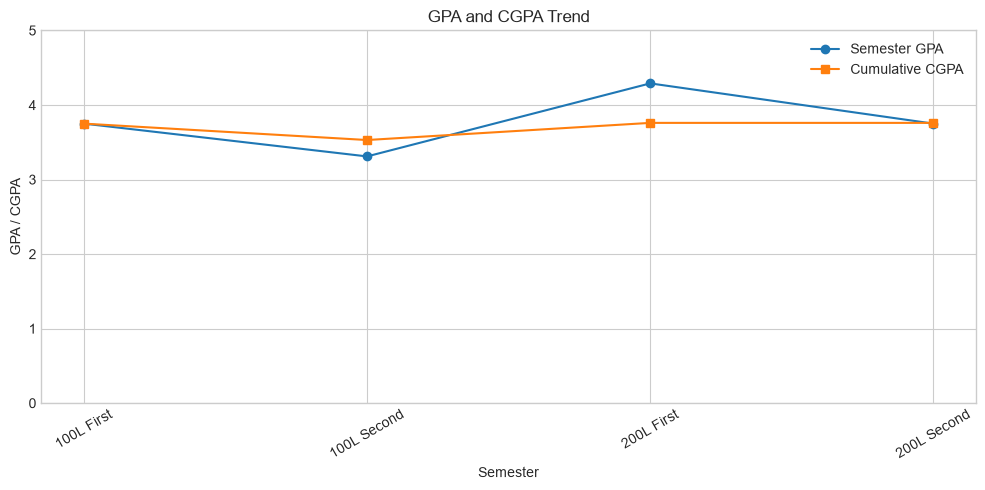

In [6]:
if cgpa_table.empty:
    print("No valid semester data available to plot.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(cgpa_table["semester"], cgpa_table["gpa"], marker="o", label="Semester GPA")
    ax.plot(cgpa_table["semester"], cgpa_table["cgpa"], marker="s", label="Cumulative CGPA")
    ax.set_title("GPA and CGPA Trend")
    ax.set_xlabel("Semester")
    ax.set_ylabel("GPA / CGPA")
    ax.set_ylim(0, 5)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [7]:
hypothetical_courses = [
    {"course": "CSC301", "units": 3, "grade": "A"},
    {"course": "MTH301", "units": 3, "grade": "B"},
    {"course": "STA301", "units": 3, "grade": "A"},
    {"course": "GST301", "units": 2, "grade": "B"},
]

projection = scenario_projection(df, hypothetical_courses, future_semester="300L First")
print(
    f"Current CGPA: {projection['current_cgpa']:.2f}. "
    f"Projected CGPA after the hypothetical semester: {projection['projected_cgpa']:.2f} "
    f"({projection['delta']:+.2f})."
)
if projection["validation"]["dropped_rows"]:
    print(f"Hypothetical rows dropped: {projection['validation']['dropped_rows']}")

Current CGPA: 3.76. Projected CGPA after the hypothetical semester: 3.88 (+0.12).


In [6]:
target = 4.20
remaining_units = 45
advice = target_cgpa_advice(df, target, remaining_units)
print(advice["message"])

You need to average at least a A (4.82) over your remaining 45 units to reach a CGPA of 4.20.


In [7]:
trend = trend_predict(cgpa_table)
print(trend["message"])

Trend projection only, not a guarantee: next semester CGPA may be about 3.80 if the current linear trend continues.


In [8]:
strong_projection = scenario_projection(
    df,
    [
        {"course": "CSC399", "units": 3, "grade": "A"},
        {"course": "MTH399", "units": 3, "grade": "A"},
        {"course": "STA399", "units": 3, "grade": "A"},
    ],
)
weak_projection = scenario_projection(
    df,
    [
        {"course": "CSC398", "units": 3, "grade": "F"},
        {"course": "MTH398", "units": 3, "grade": "E"},
        {"course": "STA398", "units": 3, "grade": "D"},
    ],
)
print(f"Strong hypothetical CGPA: {strong_projection['projected_cgpa']:.2f}")
print(f"Weak hypothetical CGPA: {weak_projection['projected_cgpa']:.2f}")

Strong hypothetical CGPA: 3.85
Weak hypothetical CGPA: 3.24
